<a href="https://colab.research.google.com/github/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/2_DL_Keras_API_funcional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creación de arquitecturas de aprendizaje profundo mediante API funcional de Keras.

- Se presentan los consideraciones básicas respecto a la [API funcional de Keras](https://keras.io/guides/functional_api/) para la implementación de modelos de redes profundas con TensorFlow.



In [1]:
import tensorflow as tf #importar tensorflow
import os 
print(tf.__version__)

2.10.0


In [2]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '2' # Suppress TensorFlow logging (1)	

gpus = tf.config.list_physical_devices('GPU')

# Activar memory growth (debe hacerse antes de crear tensores)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print('\nMemory growth activado para', gpu)
    except Exception as e:
        print('\nNo se pudo activar memory growth para', gpu, '->', e)



Memory growth activado para PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


- Se utilizará la base de datos Fashion Mnist nuevamente, normalizando las imágenes de 0 a 1.

In [3]:
train, test = tf.keras.datasets.fashion_mnist.load_data()
images, labels = train

- Se presenta un ejemplo de la base de datos

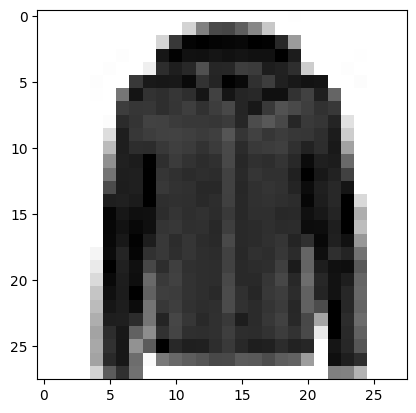

In [4]:
import matplotlib.pyplot as plt
plt.imshow(images[5000,:,:],cmap= 'binary')
plt.show()

In [5]:
import numpy as np
print(np.unique(labels)) #etiquetas
print(images.shape) #tamaño de las imágenes

[0 1 2 3 4 5 6 7 8 9]
(60000, 28, 28)


In [6]:
Xtrain, ytrain = train
Xtrain = Xtrain/255 # tipo flotante, normalizados de 0 a 1
Xtest, ytest = test
Xtest = Xtest/255 # tipo flotante, normalizados de 0 a 1

- En el cuaderno introductorio a redes neuronales con tensorflow se planteó la construcción de modelos mediante secuencia de capas:

In [7]:
#definir arquitectura secuencial
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2])),
    tf.keras.layers.Dense(200,activation="relu", name='red1'),
    tf.keras.layers.Dense(50, activation="tanh",name='hred2'),
    tf.keras.layers.Dense(10,activation='softmax',name='output')
])

model.summary() # resumen del modelo
# tf.keras.utils.plot_model(model) #diagrama del modelo

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 red1 (Dense)                (None, 200)               157000    
                                                                 
 hred2 (Dense)               (None, 50)                10050     
                                                                 
 output (Dense)              (None, 10)                510       
                                                                 
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 red1 (Dense)                (None, 200)               1

- Aunque la implementacióm mediante secuencia es intuitiva, no permite realizar conexiones flexibles entre capas.

- En ese sentido, Keras permite crear capas bajo el principio de funciones y argumentos, como se muestra a continuación.

**Nota**: a diferencia de la estructura secuencial, en la API funcional se debe indicar la capa o capas de entrada y la capa o capas de salida para crear el grafo computacional de forma apropiada.

In [8]:
#arquitectura funcional
#capa de entrada
input_l = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada')
#capa de aplanamiento de las imágenes
flatten = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_l)#argumento de entrada
#capas densas
h1 = tf.keras.layers.Dense(200,activation='tanh',name='h1')(flatten)#argumento de entrada
h2 = tf.keras.layers.Dense(50,activation='tanh',name='h2')(h1)
#capa de salida
output = tf.keras.layers.Dense(10,activation="softmax",name='output')(h2)
#crear modelo según conexiones tipo funcionales
model_fun = tf.keras.Model(inputs=input_l,outputs=output)

#resumen y gráfica del modelo
model_fun.summary()
# tf.keras.utils.plot_model(model_fun)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 entrada (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 h1 (Dense)                  (None, 200)               157000    
                                                                 
 h2 (Dense)                  (None, 50)                10050     
                                                                 
 output (Dense)              (None, 10)                510       
                                                                 
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 entrada (InputLayer)        [(None, 28, 28)]          0     

# La API funcional permite realizar conexiones más flexibles

- En el siguiente ejemplo se crea un modelo con una entrada y dos salidas con interconexiones flexibles:

In [9]:
#arquitectura funcional 2
tf.keras.backend.clear_session()
input_l = tf.keras.layers.Input(shape=(Xtrain.shape[1],Xtrain.shape[2]), name='entrada')
flatten = tf.keras.layers.Flatten(input_shape=(Xtrain.shape[1],Xtrain.shape[2]))(input_l)

h1 = tf.keras.layers.Dense(200,activation='tanh',name='h1')(flatten)
h2 = tf.keras.layers.Dense(50,activation='tanh',name='h2')(h1)
#capa que concatena caracter�sitacas extra�das en h2 con im�genes de entrada
concat = tf.keras.layers.Concatenate(name='concat')([h2,flatten])
#se crean dos salidas:
output_A = tf.keras.layers.Dense(10,activation="softmax",name='outputA')(concat)#desde concatenaci�n
output_B = tf.keras.layers.Dense(10,activation="softmax",name='outputB')(h2)#desde h2
#las entradas y salidas se ingresan como listas
model_fun = tf.keras.Model(inputs=input_l,outputs=[output_A, output_B])
#model_fun.summary()
#tf.keras.utils.plot_model(model_fun)


**Nota**: si se cuenta con varias salidas se puede definir un mismo costo para cada salida, o una lista con los costos requeridos. Además, en la lista `loss_weights` se puede especificar el valor del peso asociado al costo de cada salida en el intervalo [0,1].

In [10]:

model_fun.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="Adam",
    metrics={'outputA': 'sparse_categorical_accuracy',
             'outputB': 'sparse_categorical_accuracy'}
)


- El entrenamiento se realiza de igual forma al utilizado con el modelo secuencial.

- Como se fijaron dos salidas, se debe ingresar una lista para los argumentos ytrain.

In [11]:
history = model_fun.fit(Xtrain, [ytrain,ytrain] , epochs=10,batch_size=64, # 32, 64, 128, 256
                    validation_split=0.3) # se fija el conjunto de validación como el 20% del de train

Epoch 1/10
657/657 [==============================] - 6s 7ms/step - loss: 1.0971 - outputA_loss: 0.5717 - outputB_loss: 0.5254 - outputA_sparse_categorical_accuracy: 0.8013 - outputB_sparse_categorical_accuracy: 0.8161 - val_loss: 0.8171 - val_outputA_loss: 0.4167 - val_outputB_loss: 0.4003 - val_outputA_sparse_categorical_accuracy: 0.8509 - val_outputB_sparse_categorical_accuracy: 0.8564
Epoch 2/10
657/657 [==============================] - 6s 7ms/step - loss: 1.0971 - outputA_loss: 0.5717 - outputB_loss: 0.5254 - outputA_sparse_categorical_accuracy: 0.8013 - outputB_sparse_categorical_accuracy: 0.8161 - val_loss: 0.8171 - val_outputA_loss: 0.4167 - val_outputB_loss: 0.4003 - val_outputA_sparse_categorical_accuracy: 0.8509 - val_outputB_sparse_categorical_accuracy: 0.8564
Epoch 2/10
657/657 [==============================] - 4s 7ms/step - loss: 0.7815 - outputA_loss: 0.3958 - outputB_loss: 0.3856 - outputA_sparse_categorical_accuracy: 0.8569 - outputB_sparse_categorical_accuracy: 0.85

GPU while model is trainning:

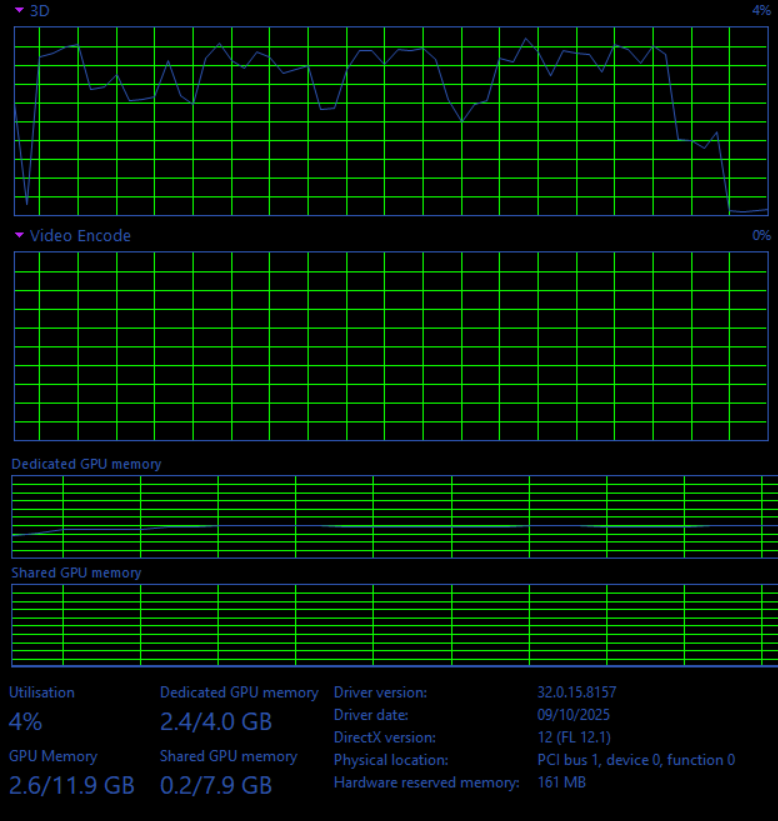

- Se presentan las curvas de desempeño:

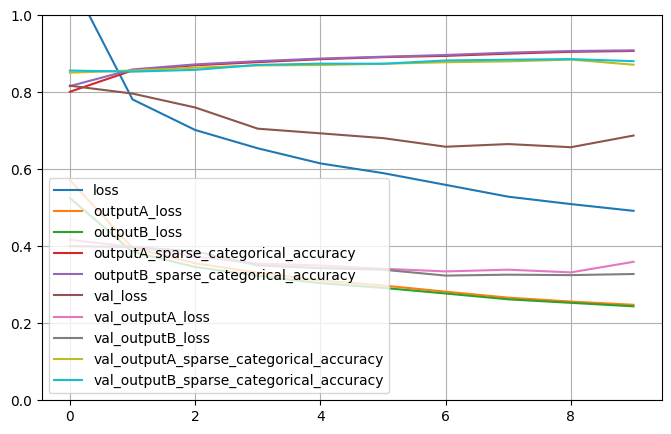

In [12]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
#save_fig("keras_learning_curves_plot")
plt.show()

- Como el modelo generado presenta dos salidas, el rendimiento se discrimina por cada salida y el acumulado.

- A la hora de predecir la salida para una nueva muestra, se debe tener en cuenta la cantidad de salidas fijadas.

In [13]:
yestA,yestB = model_fun.predict(Xtest)
print(yestA.shape,yestB.shape)#salidas tipo 1 -K probabilidad de membresia a cada clase

313/313 [==============================] - 1s 2ms/step
(10000, 10) (10000, 10)


In [14]:
print(yestA[0].argmax(),ytest[0])#para estimar la etiqueta ordinal se encuentra el max por columnas

9 9


In [15]:
scoreA = model_fun.evaluate(Xtest,[ytest,ytest])#evaluacion
print(scoreA)

313/313 [==============================] - 2s 5ms/step - loss: 0.7292 - outputA_loss: 0.3790 - outputB_loss: 0.3502 - outputA_sparse_categorical_accuracy: 0.8660 - outputB_sparse_categorical_accuracy: 0.8750
[0.7292209267616272, 0.37902647256851196, 0.35019412636756897, 0.8659999966621399, 0.875]
313/313 [==============================] - 2s 5ms/step - loss: 0.7292 - outputA_loss: 0.3790 - outputB_loss: 0.3502 - outputA_sparse_categorical_accuracy: 0.8660 - outputB_sparse_categorical_accuracy: 0.8750
[0.7292209267616272, 0.37902647256851196, 0.35019412636756897, 0.8659999966621399, 0.875]


# Grafiquemos los pesos respecto a las dimensiones de la imagen original

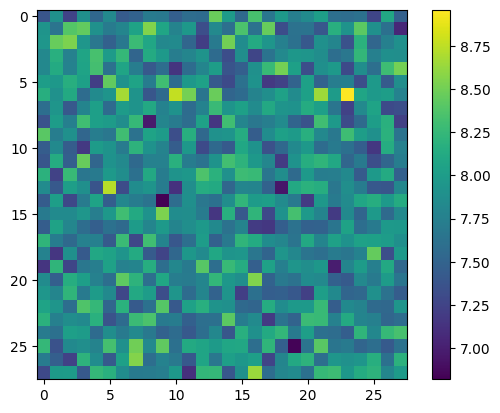

In [16]:
#se busca identificar las entradas más relevantes para la red
plt.imshow(abs(model.layers[1].get_weights()[0]).sum(axis=1).reshape(28,28))
plt.colorbar()
plt.show()

In [17]:
model.layers[1].get_weights()[1].shape # accediendo a los bias

(200,)

# Salidas parciales de la red

- La estrategia funcional nos permite acceder a partes intermedias de la red para encontrar mapas de características y verificar el aprendizaje de la representación.

In [18]:
#crear nuevo modelo con salida parcial
model_B = tf.keras.Model(inputs=model_fun.inputs,outputs=model_fun.get_layer('h2').output) #se accede a capas por nombre
# tf.keras.utils.plot_model(model_B) # modelo ya esta ajustado!


In [19]:
# Extraer y muestrear las representaciones de la capa de concatenaci�n
concat_extractor = tf.keras.Model(inputs=model_fun.inputs,
                                  outputs=model_fun.get_layer('concat').output)
concat_features = concat_extractor.predict(Xtrain, batch_size=256, verbose=0)

rng = np.random.default_rng(42)
sample_size = min(5000, concat_features.shape[0])
subset_idx = rng.choice(concat_features.shape[0], size=sample_size, replace=False)
features_subset = concat_features[subset_idx]
labels_subset = ytrain[subset_idx]
images_subset = Xtrain[subset_idx]


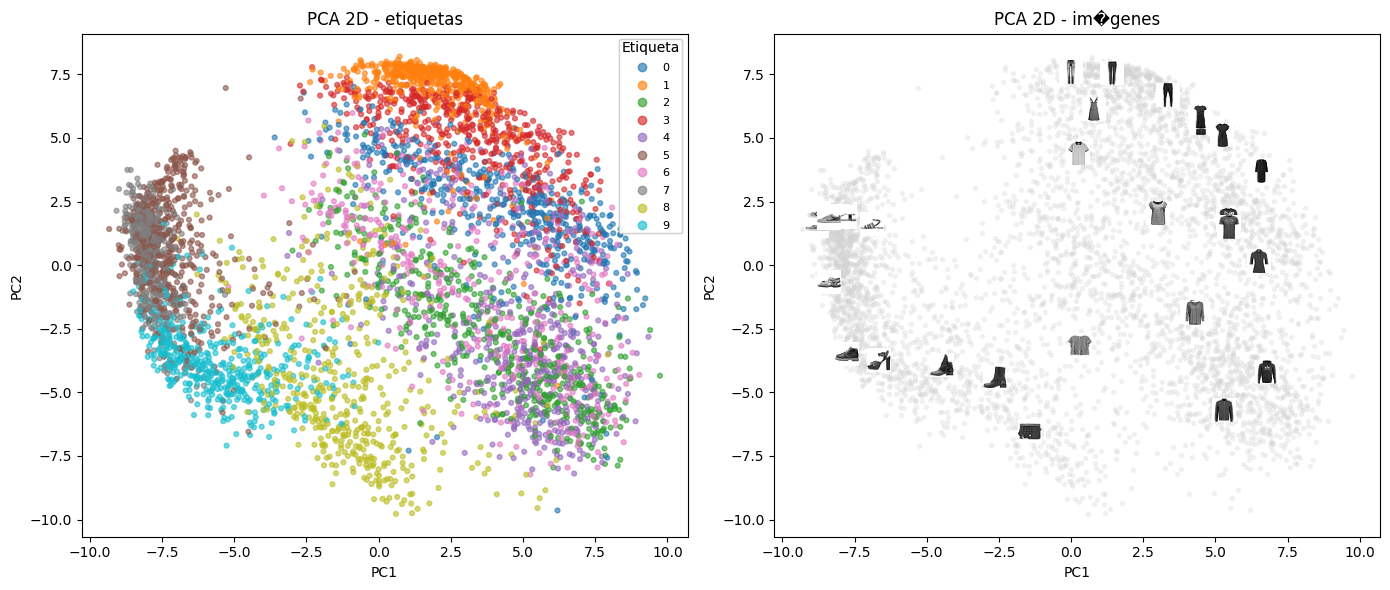

In [20]:
# PCA 2D sobre las caracter�sticas concatenadas
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

pca_model = PCA(n_components=2, random_state=42)
pca_proj = pca_model.fit_transform(features_subset)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(pca_proj[:, 0], pca_proj[:, 1], c=labels_subset,
                          cmap='tab10', s=12, alpha=0.6)
axes[0].set_title('PCA 2D - etiquetas')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
legend = axes[0].legend(*scatter.legend_elements(num=10), title='Etiqueta', fontsize=8,
                        loc='best', borderpad=0.2)
axes[0].add_artist(legend)

axes[1].set_title('PCA 2D - im�genes')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].scatter(pca_proj[:, 0], pca_proj[:, 1], c='lightgray', s=8, alpha=0.25)

sample_for_images = rng.choice(pca_proj.shape[0], size=min(30, pca_proj.shape[0]), replace=False)
for idx in sample_for_images:
    img = images_subset[idx]
    if img.ndim == 3:
        img = img.squeeze()
    imagebox = OffsetImage(img, cmap='binary', zoom=0.6)
    ab = AnnotationBbox(imagebox, (pca_proj[idx, 0], pca_proj[idx, 1]),
                        frameon=False, pad=0.02)
    axes[1].add_artist(ab)

plt.tight_layout()
plt.show()


usamos UMAP-LEARN en este caso

No fue posible utilizar RAPIDS cuML (No module named 'cuml'). Se emplea umap-learn.


a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


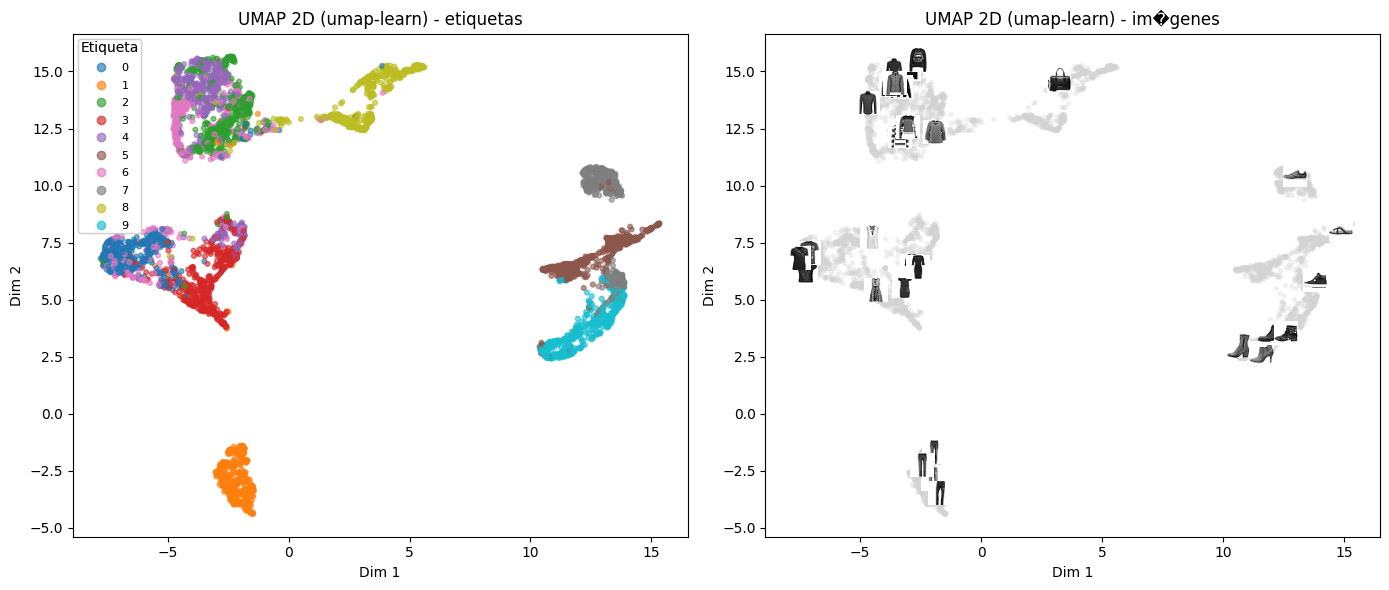

In [21]:
# UMAP 2D (RAPIDS cuML si est� disponible)
try:
    from cuml.manifold import UMAP as CumlUMAP
    import cupy as cp
    umap_model = CumlUMAP(n_components=2, random_state=42)
    umap_proj_gpu = umap_model.fit_transform(cp.asarray(features_subset))
    umap_proj = cp.asnumpy(umap_proj_gpu)
    umap_backend = 'RAPIDS cuML'
except Exception as exc:
    print(f'No fue posible utilizar RAPIDS cuML ({exc}). Se emplea umap-learn.')
    import umap
    umap_model = umap.UMAP(n_components=2, random_state=42)
    umap_proj = umap_model.fit_transform(features_subset)
    umap_backend = 'umap-learn'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(umap_proj[:, 0], umap_proj[:, 1], c=labels_subset,
                          cmap='tab10', s=12, alpha=0.6)
axes[0].set_title(f'UMAP 2D ({umap_backend}) - etiquetas')
axes[0].set_xlabel('Dim 1')
axes[0].set_ylabel('Dim 2')
legend = axes[0].legend(*scatter.legend_elements(num=10), title='Etiqueta', fontsize=8,
                        loc='best', borderpad=0.2)
axes[0].add_artist(legend)

axes[1].set_title(f'UMAP 2D ({umap_backend}) - im�genes')
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')
axes[1].scatter(umap_proj[:, 0], umap_proj[:, 1], c='lightgray', s=8, alpha=0.25)

sample_for_images = rng.choice(umap_proj.shape[0], size=min(30, umap_proj.shape[0]), replace=False)
for idx in sample_for_images:
    img = images_subset[idx]
    if img.ndim == 3:
        img = img.squeeze()
    imagebox = OffsetImage(img, cmap='binary', zoom=0.6)
    ab = AnnotationBbox(imagebox, (umap_proj[idx, 0], umap_proj[idx, 1]),
                        frameon=False, pad=0.02)
    axes[1].add_artist(ab)

plt.tight_layout()
plt.show()


In [22]:
z = model_B.predict(Xtest) # salida en h2
z.shape

313/313 [==============================] - 0s 1ms/step


(10000, 50)

# Principal Component Analysis (PCA)


### Dado que se fijaron 50 unidades, se pueden utilizar técnicas de reducción de dimensión para visualizar los patrones intermedios de la red en 2D.





Reducción de dimensión lineal basado en la preservación de la varianza

![PCA1](https://www.soloentendidos.com/wp-content/uploads/2021/06/Principal-Component-Analysis-second-principal_thumb-1.gif)


![PCA2](https://1.bp.blogspot.com/-pgMAHiIWvuw/Tql5HIXNdRI/AAAAAAAABLI/I2zPF5cLRwQ/s1600/clust.gif)


# t-student distributed Stochastic Neighbor Embedding (t-SNE)

Reducción de dimensión basado en la preservación de localidades (vecinos) utilizando medidas de información desde estimación no paramétrica de probabilidad en el espación de alta y baja dimensión, respectivamente.

![tsne](https://learnopencv.com/wp-content/uploads/2022/11/tsne.gif)

![tsne2](https://3.bp.blogspot.com/-NE01azL_JxU/Wxli17oYNzI/AAAAAAAACxQ/axOI2yy-Ft0QbqaekOyemm5Xn0wAFvRUwCLcBGAs/s640/image2.gif)

In [23]:
from sklearn.decomposition import PCA
zpca = PCA(n_components=2).fit_transform(z)
zpca.shape

(10000, 2)

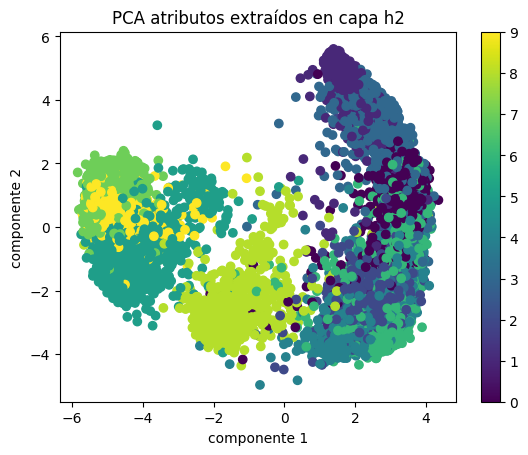

In [24]:
plt.scatter(zpca[:,0],zpca[:,1],c=ytest)
plt.colorbar()
plt.xlabel('componente 1')
plt.ylabel('componente 2')
plt.title('PCA atributos extraídos en capa h2')
plt.show()

In [25]:
#plot mnist 2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
def plot_mnist_2d(Z,y,images,img_w=28,img_h=28,zoom=0.5,cmap='jet'):
    fig, ax = plt.subplots(figsize=(16,10))
    for i in range(Z.shape[0]):
        #print('img',i+1,'/',Z.shape[0])
        image = images[i].reshape((img_w, img_h))
        im = OffsetImage(image, zoom=zoom,cmap=cmap)
        ab = AnnotationBbox(im, (Z[i,0], Z[i,1]), xycoords='data', frameon=False)
        ax.add_artist(ab)
        ax.update_datalim([(Z[i,0], Z[i,1])])
        ax.autoscale()

- También, podemos revisar la distribución de las imágenes en el espacio proyectado:

Text(0.5, 1.0, 'PCA atributos extraídos en capa h2')

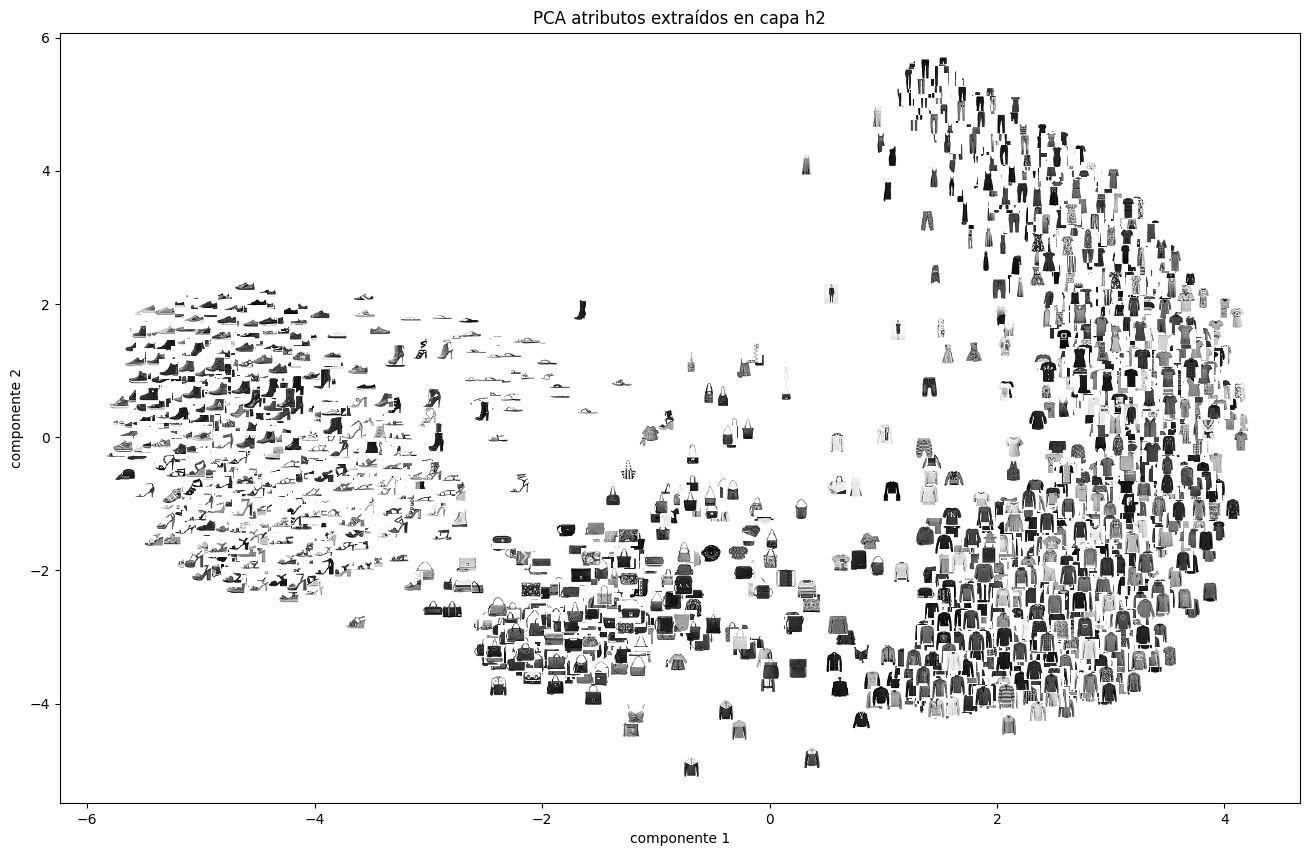

In [26]:
Ni =4000 # graficar Ni muestras como imagenes en espacio 2D
ind = np.random.randint(0,ytest.shape[0],Ni)
plot_mnist_2d(zpca[ind],ytest[ind],Xtest[ind],img_w=28,img_h=28,zoom=0.5,cmap='binary')
plt.xlabel('componente 1')
plt.ylabel('componente 2')
plt.title('PCA atributos extraídos en capa h2')

# Ejercicio:

- Grafique el espacio proyectado de PCA en 2D (etiquetas e imágenes) para los atributos aprendidos por la capa de concatenación.

- Repita el proceso aplicando la técnica de reducción de dimensión [UMAP de RAPIDS](https://developer.nvidia.com/blog/even-faster-and-more-scalable-umap-on-the-gpu-with-rapids-cuml/).

- Plantee una nueva arquitectura tipo funcional utilizando capas convolucionales (Ver cuaderno [CNNs](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/5_DeepLearning/3_Introduccion_CNN.ipynb)) para el entrenamiento de la base de datos Mnist-digitos, utilizando tres entradas: i) imágenes limpias, ii) y iii) imágenes con ruido blanco Gaussiano ante diferentes varianzas, y dos salidas i) estimación del digito, ii) estimación número par número impar.

## PCA 2D de las características de la capa de concatenación

A continuación extraemos las características (activaciones) de la capa de concatenación del modelo, reducimos a 2 dimensiones con PCA, y mostramos:
- **Izquierda**: diagrama de dispersión coloreado por etiquetas.
- **Derecha**: proyección con miniaturas (thumbnails) de las imágenes seleccionadas.

El código intenta detectar automáticamente el modelo y la capa de concatenación disponibles en el entorno.

Usando modelo: model, capa de concat detectada: concat
Datos encontrados: (60000, 28, 28) (60000,)
Features extraídas. shape = (60000, 834)
Features extraídas. shape = (60000, 834)
Explained variance ratio (PC1, PC2): [0.263 0.169]
Explained variance ratio (PC1, PC2): [0.263 0.169]


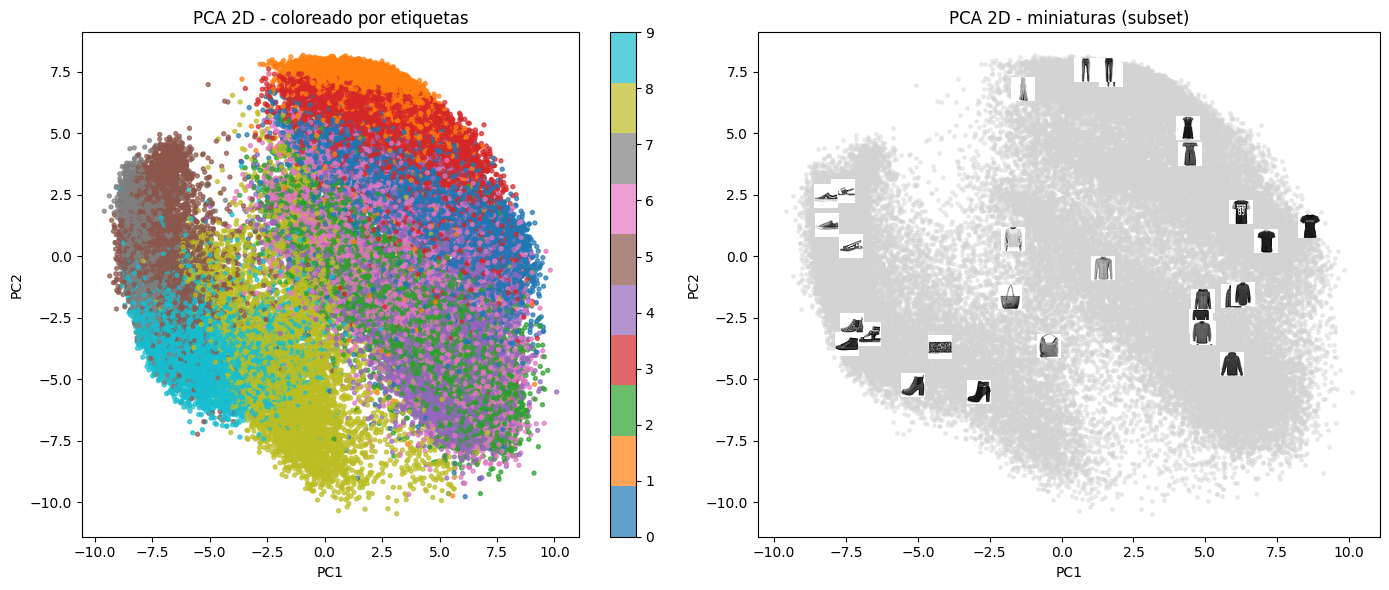

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.decomposition import PCA
from tensorflow import keras

# ------------- 1) Localizar modelo y capa de concatenación -------------
possible_models = []
for name in ['model_fun', 'model', 'model_cnn', 'model_fun2', 'model_B']:
    m = globals().get(name)
    if m is not None and isinstance(m, keras.Model):
        possible_models.append((name, m))

concat_layer_name = None
model_obj = None
for name, m in possible_models:
    for candidate in ['concat', 'fusion_concat', 'concat_cnn', 'concat_cnn', 'concat']:
        try:
            _ = m.get_layer(candidate)
            concat_layer_name = candidate
            model_obj = m
            break
        except Exception:
            pass
    if concat_layer_name is not None:
        break

if model_obj is None:
    raise RuntimeError('No se encontró un modelo válido con nombre conocido (model_fun/model). Asegúrate de ejecutar la celda que crea el modelo primero.')

print(f"Usando modelo: {model_obj.name}, capa de concat detectada: {concat_layer_name}")

# ------------- 2) Localizar datos (imágenes y etiquetas) -------------
def find_data():
    candidates = [
        ('Xtrain','ytrain'), ('X_train','y_train'), ('x_train','y_train'),
        ('Xtest','ytest'), ('x_test','y_test'), ('X_train','y_train'),
    ]
    for xname, yname in candidates:
        X = globals().get(xname)
        y = globals().get(yname)
        if X is not None and y is not None:
            return X, y
    # si no encuentra pares de train, intenta pares x_test/y_test
    for xname, yname in candidates:
        X = globals().get(xname)
        y = globals().get(yname)
        if X is not None and y is not None:
            return X, y
    raise RuntimeError('No se encontraron arrays de datos (Xtrain/ytrain o x_train/y_train).')

X_all, y_all = find_data()
print('Datos encontrados:', X_all.shape, y_all.shape)

# Usaremos el conjunto de prueba si está disponible (mejor para visualizar generalización)
X_data = X_all
y_data = y_all

# ------------- 3) Construir extractor de la capa de concatenación -------------
extractor = keras.Model(inputs=model_obj.inputs, outputs=model_obj.get_layer(concat_layer_name).output)

# ------------- 4) Extraer features (activaciones) -------------
# Si el extractor espera múltiples entradas (lista/dict), intentamos acomodarlo:
def run_extractor(X):
    try:
        return extractor.predict(X, batch_size=256, verbose=0)
    except Exception as exc:
        # si el modelo tiene múltiples entradas y X es un array de imágenes, duplicarlo
        if isinstance(model_obj.input, list) or (hasattr(model_obj, 'inputs') and len(model_obj.inputs) > 1):
            n_inputs = len(model_obj.inputs)
            X_list = [X] * n_inputs
            return extractor.predict(X_list, batch_size=256, verbose=0)
        raise

features = run_extractor(X_data)
features_shape = features.shape
print('Features extraídas. shape =', features_shape)

# Si las features son imagen-like (ej: N, H, W, C), las aplanamos para PCA
if features.ndim > 2:
    features_flat = features.reshape(features.shape[0], -1)
else:
    features_flat = features

# ------------- 5) PCA 2D -------------
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(features_flat)
print('Explained variance ratio (PC1, PC2):', pca.explained_variance_ratio_.round(3))

# ------------- 6) Gráficos: scatter por etiquetas y miniaturas -------------
def imshow_from_X(X, idx):
    img = X[idx]
    # soportar formatos (H,W) o (H,W,1) o (H*W,)
    if img.ndim == 3 and img.shape[2] == 1:
        img = img.squeeze(-1)
    if img.ndim == 1:
        size = int(np.sqrt(img.size))
        img = img.reshape(size, size)
    return img

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
scatter = plt.scatter(proj[:,0], proj[:,1], c=y_data, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(len(np.unique(y_data))))
plt.title('PCA 2D - coloreado por etiquetas')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1,2,2)
plt.scatter(proj[:,0], proj[:,1], c='lightgray', s=6, alpha=0.4)
plt.title('PCA 2D - miniaturas (subset)')

# Añadir miniaturas (hasta 30) — elegimos un subconjunto balanceado por etiquetas si es posible
n_thumb = 30
N = proj.shape[0]
rng = np.random.default_rng(42)
if N <= n_thumb:
    idxs = np.arange(N)
else:
    # intentar muestrear por etiquetas para variedad
    labels = np.unique(y_data)
    idxs = []
    per_label = max(1, n_thumb // max(1, len(labels)))
    for lab in labels:
        lab_idx = np.where(y_data == lab)[0]
        if lab_idx.size > 0:
            pick = rng.choice(lab_idx, size=min(per_label, lab_idx.size), replace=False).tolist()
            idxs.extend(pick)
    # completar aleatoriamente si faltan
    if len(idxs) < n_thumb:
        remaining = list(set(range(N)) - set(idxs))
        if remaining:
            extra = rng.choice(remaining, size=min(n_thumb - len(idxs), len(remaining)), replace=False).tolist()
            idxs.extend(extra)
    idxs = np.array(idxs[:n_thumb])

ax = plt.gca()
for i in idxs:
    img = imshow_from_X(X_data, i)
    im = OffsetImage(img, cmap='binary', zoom=0.6)
    ab = AnnotationBbox(im, (proj[i,0], proj[i,1]), frameon=False, pad=0.02)
    ax.add_artist(ab)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


### Solución del ejercicio (PCA/UMAP y arquitectura funcional conv)
Se construye una arquitectura funcional con tres entradas (imagen limpia y dos versiones con ruido), dos salidas (clasificación de dígitos y paridad), y se proyectan las características fusionadas a 2D usando PCA y UMAP (cae a `umap-learn` si RAPIDS no está disponible).


Evaluación: [0.46758756041526794, 0.39074385166168213, 0.07684384286403656, 0.8568999767303467, 0.9706000089645386]


a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


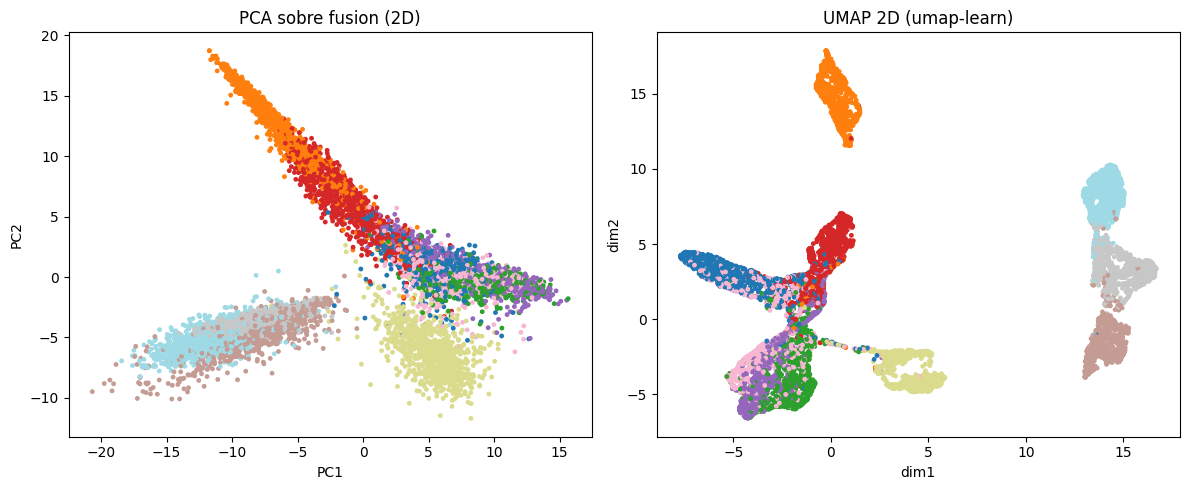

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) Datos y etiquetas auxiliares
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
parity_train = (y_train % 2).astype("float32")
parity_test = (y_test % 2).astype("float32")

# Reducir tamaño para rapidez (se puede quitar para entrenar completo)
train_subset = 12000
x_train = x_train[:train_subset]
y_train = y_train[:train_subset]
parity_train = parity_train[:train_subset]

# 2) Generar versiones con ruido
rng = np.random.default_rng(42)

def add_noise(imgs, std):
    noise = rng.normal(0.0, std, size=imgs.shape)
    noisy = np.clip(imgs + noise, 0.0, 1.0)
    return noisy

x_train_clean = x_train[..., np.newaxis]
x_test_clean = x_test[..., np.newaxis]
x_train_n1 = add_noise(x_train_clean, 0.1)
x_train_n2 = add_noise(x_train_clean, 0.25)
x_test_n1 = add_noise(x_test_clean, 0.1)
x_test_n2 = add_noise(x_test_clean, 0.25)

# 3) Arquitectura funcional multi-entrada
keras.backend.clear_session()
inputs = {
    "clean": keras.layers.Input(shape=(28, 28, 1), name="clean"),
    "noise01": keras.layers.Input(shape=(28, 28, 1), name="noise01"),
    "noise025": keras.layers.Input(shape=(28, 28, 1), name="noise025"),
}

def conv_branch(x, prefix):
    y = keras.layers.Conv2D(32, 3, padding="same", activation="relu", name=f"{prefix}_c1")(x)
    y = keras.layers.MaxPooling2D()(y)
    y = keras.layers.Conv2D(64, 3, padding="same", activation="relu", name=f"{prefix}_c2")(y)
    y = keras.layers.MaxPooling2D()(y)
    y = keras.layers.Flatten()(y)
    return y

branches = [
    conv_branch(inputs["clean"], "b0"),
    conv_branch(inputs["noise01"], "b1"),
    conv_branch(inputs["noise025"], "b2"),
]
concat = keras.layers.Concatenate(name="fusion_concat")(branches)
fusion = keras.layers.Dense(256, activation="relu", name="fusion_dense1")(concat)
fusion = keras.layers.Dropout(0.3)(fusion)
fusion = keras.layers.Dense(128, activation="relu", name="fusion_dense2")(fusion)

out_digit = keras.layers.Dense(10, activation="softmax", name="digit")(fusion)
out_parity = keras.layers.Dense(1, activation="sigmoid", name="parity")(fusion)

model = keras.Model(inputs=list(inputs.values()), outputs=[out_digit, out_parity], name="multi_input_cnn")
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss={"digit": "sparse_categorical_crossentropy", "parity": "binary_crossentropy"},
    metrics={"digit": "accuracy", "parity": "accuracy"},
)

# 4) Entrenamiento breve
history = model.fit(
    {"clean": x_train_clean, "noise01": x_train_n1, "noise025": x_train_n2},
    {"digit": y_train, "parity": parity_train},
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    verbose=0,
)
print("Evaluación:", model.evaluate(
    {"clean": x_test_clean, "noise01": x_test_n1, "noise025": x_test_n2},
    {"digit": y_test, "parity": parity_test},
    verbose=0,
))

# 5) Proyección PCA/UMAP de la capa fusion
feature_extractor = keras.Model(inputs=model.inputs, outputs=model.get_layer("fusion_dense2").output)
features = feature_extractor.predict(
    {"clean": x_test_clean, "noise01": x_test_n1, "noise025": x_test_n2},
    batch_size=256,
    verbose=0,
)

pca = PCA(n_components=2, random_state=42)
pca_proj = pca.fit_transform(features)

try:
    from cuml.manifold import UMAP as CumlUMAP
    import cupy as cp
    umap_model = CumlUMAP(n_components=2, random_state=42)
    umap_proj = cp.asnumpy(umap_model.fit_transform(cp.asarray(features)))
    umap_backend = "cuML"
except Exception:
    import umap
    umap_model = umap.UMAP(n_components=2, random_state=42)
    umap_proj = umap_model.fit_transform(features)
    umap_backend = "umap-learn"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(pca_proj[:, 0], pca_proj[:, 1], c=y_test, s=6, cmap="tab20")
axes[0].set_title("PCA sobre fusion (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(umap_proj[:, 0], umap_proj[:, 1], c=y_test, s=6, cmap="tab20")
axes[1].set_title(f"UMAP 2D ({umap_backend})")
axes[1].set_xlabel("dim1")
axes[1].set_ylabel("dim2")
plt.tight_layout()
plt.show()

